# IS 4487 Lab 11

## Learning Objective

Use Linear Regression to predict the AQI in Utah.

## Outline

- Pull the latest "Daily AQI by County" file from this link: https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI

- Your target variable will be *AQI", which is the value of the air quality index

- We will focus the analysis on only the air quality in the state of Utah.  

- Note that there is a several-month lag in preparing data; you should check to see if your file has a full year of data from January to December.  If not, use the previous year.    

- The AQI is divided into six categories:

*Air Quality Index*

|(AQI) Values	|Levels of Health Concern	        |
|---------------|--------|
|0-50	        |Good	 |
|51-100	        |Moderate	 |
|101-150	    |Unhealthy for Sensitive Groups	|
|151 to 200	    |Unhealthy	 |
|201 to 300	    |Very Unhealthy	 |
|301 to 500	    |Hazardous	 |

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_11_air_quality_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [43]:
import pandas as pd
import matplotlib as mpl
import sklearn as sl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Import Data into Dataframe

➡️ Assignment Tasks
- Pull the latest full year of data using the "Daily AQI by County" files from this link: https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
- Make sure to UNZIP the file
- Import data from the air quality dataset into a dataframe
- Describe or profile the dataframe

In [44]:
df = pd.read_csv('daily_aqi_by_county_2024.csv')
print(df)

       State Name county Name  State Code  County Code        Date  AQI  \
0         Alabama     Baldwin           1            3  2024-01-03   41   
1         Alabama     Baldwin           1            3  2024-01-04   38   
2         Alabama     Baldwin           1            3  2024-01-05   44   
3         Alabama     Baldwin           1            3  2024-01-06    7   
4         Alabama     Baldwin           1            3  2024-01-07   29   
...           ...         ...         ...          ...         ...  ...   
206914    Wyoming      Weston          56           45  2024-06-26   45   
206915    Wyoming      Weston          56           45  2024-06-27   48   
206916    Wyoming      Weston          56           45  2024-06-28   47   
206917    Wyoming      Weston          56           45  2024-06-29   37   
206918    Wyoming      Weston          56           45  2024-06-30   47   

       Category Defining Parameter Defining Site  Number of Sites Reporting  
0          Good      

## Prepare Data

➡️ Assignment Tasks
- Filter the data to use Utah data only
- Create one dummy variable (true/false) for each of the Defining Parameter values    
- Create variables for month of year, year, and season
- Perform any other data cleanup needed (remove outliers, nulls, etc.)
- After filtering for Utah, remove the geographical variables that remain (county, state) since those non-numeric values can't be used.  Remove any other non-numeric variables.
- Select the data you would like to use in the model.  If you aggregate data, you will have to decide whether to use the min, max or mean value for AQI
- Split the data 80/20 for training and testing

In [45]:
utah_data = df[df['State Name'] == 'Utah']

In [46]:
# Create dummy variables for 'Defining Parameter'
defining_parameter_dummies = pd.get_dummies(utah_data['Defining Parameter'], prefix='DP')
utah_data = pd.concat([utah_data, defining_parameter_dummies], axis=1)

# Create month, year, and season variables
utah_data['Date'] = pd.to_datetime(utah_data['Date'])
utah_data['Month'] = utah_data['Date'].dt.month
utah_data['Year'] = utah_data['Date'].dt.year

# Define a function to determine the season
def get_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

utah_data['Season'] = utah_data['Month'].apply(get_season)

#Further data cleaning (example, replace with your specific needs)
utah_data = utah_data.drop(['State Name','county Name','State Code','County Code'], axis=1)
utah_data = utah_data.dropna()

#Convert AQI and other relevant columns to numeric
utah_data['AQI'] = pd.to_numeric(utah_data['AQI'])
#add other columns as needed

#Example of creating a season dummy variables
season_dummies = pd.get_dummies(utah_data['Season'], prefix='Season')
utah_data = pd.concat([utah_data, season_dummies], axis=1)
utah_data = utah_data.drop(['Season'], axis = 1)

#Example of creating a month dummy variable
month_dummies = pd.get_dummies(utah_data['Month'], prefix='Month')
utah_data = pd.concat([utah_data, month_dummies], axis=1)
utah_data = utah_data.drop(['Month'], axis = 1)



print(utah_data.head())


             Date  AQI  Category Defining Parameter Defining Site  \
178824 2024-01-01   71  Moderate              PM2.5   49-003-0005   
178825 2024-01-02   64  Moderate              PM2.5   49-003-0005   
178826 2024-01-03   66  Moderate              PM2.5   49-003-0005   
178827 2024-01-04   60  Moderate              PM2.5   49-003-0005   
178828 2024-01-05   29      Good              Ozone   49-003-7001   

        Number of Sites Reporting  DP_CO  DP_NO2  DP_Ozone  DP_PM10  ...  \
178824                          2  False   False     False    False  ...   
178825                          2  False   False     False    False  ...   
178826                          2  False   False     False    False  ...   
178827                          2  False   False     False    False  ...   
178828                          2  False   False      True    False  ...   

        Month_2  Month_3  Month_4  Month_5  Month_6  Month_7  Month_8  \
178824    False    False    False    False    False    

In [47]:
# Select relevant columns (numeric only after removing geographical variables)
numeric_cols = utah_data.select_dtypes(include=np.number).columns
utah_data_numeric = utah_data[numeric_cols]

# Display the selected numeric columns
print(utah_data_numeric.head())


# Separate features (X) and target (y)
X = utah_data_numeric.drop('AQI', axis=1)  # Features
y = utah_data_numeric['AQI']  # Target variable


# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #random state for reproducibility

print("Shapes of training and testing sets:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


        AQI  Number of Sites Reporting  Year
178824   71                          2  2024
178825   64                          2  2024
178826   66                          2  2024
178827   60                          2  2024
178828   29                          2  2024
Shapes of training and testing sets:
X_train: (3364, 2)
X_test: (842, 2)
y_train: (3364,)
y_test: (842,)


In [48]:
# Select the final columns for the model (example, replace with your desired columns).
# This example includes 'Year', 'DP_Ozone', 'Month_1', 'Month_12', and all other numeric columns.

final_columns = ['Year', 'DP_Ozone', 'Month_1', 'Month_12']  # Add your other columns here

# Check if the specified columns exist in the DataFrame before selecting them.
# If a column is not found, it will be removed from final_columns
# This prevents the KeyError
final_columns = [col for col in final_columns if col in utah_data_numeric.columns]

# Select the specified columns from the DataFrame.
selected_data = utah_data_numeric[final_columns]

# You can further process the 'selected_data' DataFrame (e.g., scaling, feature engineering).
# ... your code here ...

print(selected_data.head())


        Year
178824  2024
178825  2024
178826  2024
178827  2024
178828  2024


## Create Model

➡️ Assignment Tasks
- Create a simple linear regression to predict AQI based on as many variables as you can use or derive.  (for example, sklearn LinearRegression)
- Evaluate the model by displaying the R squared value  
- Visualize the correlation between the target variable and at least one of the independent variables

R-squared: 0.027546341223792403


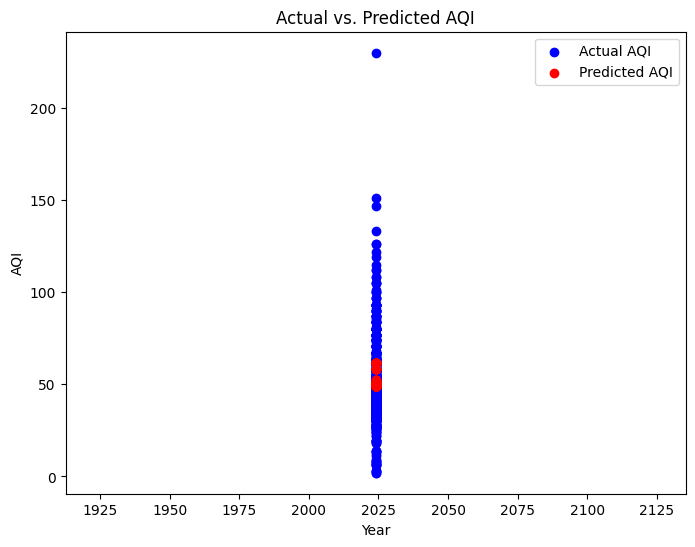

In [49]:
# Initialize the linear regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

# Visualize the correlation (example with 'Year')
plt.figure(figsize=(8, 6))
plt.scatter(X_test['Year'], y_test, color='blue', label='Actual AQI')
plt.scatter(X_test['Year'], y_pred, color='red', label='Predicted AQI')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.title('Actual vs. Predicted AQI')
plt.legend()
plt.show()


## Make a prediction

➡️ Assignment Tasks
- What would you predict the average AQI to be in January of the upcoming year?  

In [61]:
# Get the upcoming year
upcoming_year = pd.to_datetime('today').year + 1

# Create a DataFrame with the same columns as X_train and initialize to 0
january_data = pd.DataFrame(0, index=[0], columns=X_train.columns)


# Set known values for the upcoming year
january_data['Year'] = upcoming_year

# If 'Number of Sites Reporting' is in X_train, set it to the average
# You can adjust this to a more appropriate value if needed
if 'Number of Sites Reporting' in X_train.columns:
    january_data['Number of Sites Reporting'] = X_train['Number of Sites Reporting'].mean()

# If 'DP_Ozone' is in X_train, set it to the average
if 'DP_Ozone' in X_train.columns:
    january_data['DP_Ozone'] = X_train['DP_Ozone'].mean()

# Make prediction
january_prediction = model.predict(january_data)

print(f"Predicted average AQI for January {upcoming_year}: {january_prediction[0]}")

Predicted average AQI for January 2026: 50.34036860879905


## OPTIONAL: Compare Air Quality

➡️ Assignment Tasks
- Download the data from several previous years using this website: https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
- Append the new data to the previous dataframe
- Use the year as a variable in your regression.  Is year a significant factor in predicting AQI?

In [ ]:
#import, append and create new model